In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
TRAIN_PATH = "smartvision_dataset/classification/train"
VAL_PATH = "smartvision_dataset/classification/val"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

2026-04-18 19:57:27.505188: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-18 19:57:27.505215: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-18 19:57:27.505224: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-18 19:57:27.505260: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-18 19:57:27.505279: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
for layer in base_model.layers:
    layer.trainable = False

In [6]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1
)

Epoch 1/15


2026-04-18 19:57:29.411151: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-18 19:57:29.463143: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


55/55 [==============================] - 12s 161ms/step - loss: 4.1623 - accuracy: 0.0520 - val_loss: 3.1282 - val_accuracy: 0.1387
Epoch 2/15
55/55 [==============================] - 8s 149ms/step - loss: 3.7010 - accuracy: 0.0994 - val_loss: 2.8138 - val_accuracy: 0.2213
Epoch 3/15
55/55 [==============================] - 8s 152ms/step - loss: 3.4731 - accuracy: 0.1411 - val_loss: 2.5559 - val_accuracy: 0.2987
Epoch 4/15
55/55 [==============================] - 9s 155ms/step - loss: 3.1869 - accuracy: 0.1926 - val_loss: 2.3922 - val_accuracy: 0.3547
Epoch 5/15
55/55 [==============================] - 9s 157ms/step - loss: 2.9411 - accuracy: 0.2303 - val_loss: 2.2175 - val_accuracy: 0.3653
Epoch 6/15
55/55 [==============================] - 8s 153ms/step - loss: 2.7287 - accuracy: 0.2754 - val_loss: 2.0935 - val_accuracy: 0.4133
Epoch 7/15
55/55 [==============================] - 9s 153ms/step - loss: 2.5586 - accuracy: 0.3137 - val_loss: 1.9755 - val_accuracy: 0.4720
Epoch 8/15
55/55

In [11]:
print(train_generator.class_indices)

{'airplane': 0, 'bed': 1, 'bench': 2, 'bicycle': 3, 'bird': 4, 'bottle': 5, 'bowl': 6, 'bus': 7, 'cake': 8, 'car': 9, 'cat': 10, 'chair': 11, 'couch': 12, 'cow': 13, 'cup': 14, 'dog': 15, 'elephant': 16, 'horse': 17, 'motorcycle': 18, 'person': 19, 'pizza': 20, 'potted plant': 21, 'stop sign': 22, 'traffic light': 23, 'truck': 24}


In [9]:
model.save("models/mobilenet_model.h5")
print("MobileNet Model Saved ✅")

MobileNet Model Saved ✅


/Users/sabari/Documents/DS/GUVI/SmartVision-AI/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


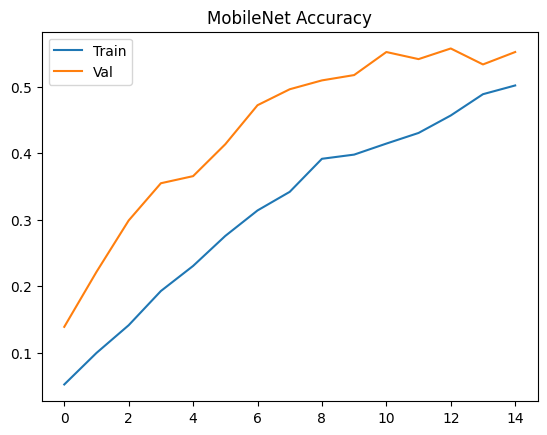

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("MobileNet Accuracy")
plt.legend(["Train","Val"])
plt.show()